In [1]:
### use conda env valis_registration

from valis import registration
import tifffile as tiff
from matplotlib import pyplot as plt
from aicsimageio import AICSImage
from tifffile import imsave
from PIL import Image
import numpy as np
import os
import pandas as pd
import gzip

/home/shamini/anaconda3/envs/valis_registration/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root = '/home/shamini/data2/projects/chiba_pathomics/'
data_dir = root + 'data/'
#xenium_dir = data_dir + 'Xenium Output Glioma TMA/'
xenium_dir = root+'data/xenium_redownload/Xenium Output Glioma TMA/'

out_root = root + 'out_feb2025_final/'
os.makedirs(out_root, exist_ok=True)

slide_src_dir = out_root+'script01ab_converted_images_for_valis_reg/reg01_dapi_he/'


## valis registration output paths and folders
reg_outpath = out_root + 'script01b_registration_out_xeDapi_he__high_res_he_/'
os.makedirs(reg_outpath, exist_ok=True)

results_dst_dir = reg_outpath+"/results"
registered_slide_dst_dir = reg_outpath+"/registered"

os.listdir(slide_src_dir)

['he_rotated_3dim.tif', 'morphology_focus_valis.tiff']

In [3]:
  
#he_images = [img for img in images if 'he' in img]
reference_slide = 'he_rotated_3dim.tif'
dapi_slide = 'morphology_focus_valis.tiff'
#reference_slide = 'morphology_focus_valis.tiff'
    
#print(reference_slide, dapi_slide)
    

### create a Valis object
registrar = registration.Valis(slide_src_dir, 
                               results_dst_dir, 
                               check_for_reflections=True, 
                               reference_img_f=reference_slide, 
                               align_to_reference=True
                               )
rigid_registrar, non_regid_registrar, error_df = registrar.register()
  
### perform micro-registration
#registrar.register_micro(align_to_reference=True)
    
registrar.warp_and_save_slides(registered_slide_dst_dir, crop='reference')
    


SLF4J: No SLF4J providers were found.
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See https://www.slf4j.org/codes.html#noProviders for further details.


JVM has been initialized. Be sure to call registration.kill_jvm() or slide_io.kill_jvm() at the end of your script.

==== Converting images



Converting images:   0%|          | 0/2 [00:00<?, ?image/s]

<Slide, name = he_rotated_3dim>, width=6000, height=11500, channels=3, levels=1, RGB=True, dtype=uint8> <valis.slide_io.VipsSlideReader object at 0x7ff912bca800> True (1024, 534, 3)


Converting images:  50%|█████     | 1/2 [00:00<00:00,  1.78image/s]

...

Saving images:   0%|          | 0/2 [00:00<?, ?image/s]/home/shamini/anaconda3/envs/valis_registration/lib/python3.10/site-packages/valis/valtils.py:25: UserWarning: xml in original file is invalid or missing. Will create one
  warnings.warn(warning_msg, warning_type)


Traceback (most recent call last):
  File "/home/shamini/anaconda3/envs/valis_registration/lib/python3.10/site-packages/valis/slide_io.py", line 3358, in update_xml_for_new_img
    elementTree.fromstring(current_ome_xml_str)
  File "/home/shamini/anaconda3/envs/valis_registration/lib/python3.10/xml/etree/ElementTree.py", line 1347, in XML
    parser.feed(text)
xml.etree.ElementTree.ParseError: not well-formed (invalid token): line 1, column 0

saving /home/shamini/data2/projects/chiba_pathomics/out_feb2025_final/script01b_registration_out_xeDapi_he__high_res_he_//registered/he_rotated_3dim.ome.tiff (6000 x 11500 and 3 channels)

[====================================================================================================] 100.0% in 5.163 seconds
Complete



Saving images:  50%|█████     | 1/2 [00:05<00:05,  5.30s/image]

saving /home/shamini/data2/projects/chiba_pathomics/out_feb2025_final/script01b_registration_out_xeDapi_he__high_res_he_//registered/morphology_focus_valis.ome.tiff (6000 x 11500 and 1 channels)

[====================================================================================================] 100.0% in 10.795 seconds
Complete



Saving images: 100%|██████████| 2/2 [00:17<00:00,  8.81s/image]


In [4]:

src_obj = registrar.get_slide(dapi_slide)
ref_reg = registrar.get_slide(reference_slide)


geom = pd.read_parquet(xenium_dir + 'cell_boundaries.parquet')
tf = pd.read_parquet(xenium_dir + 'transcripts.parquet')                        
cells = pd.read_parquet(xenium_dir + 'cells.parquet')
                
geom_coord_px = geom[['vertex_x', 'vertex_y']].values/0.2125
tf_coord_px = tf[['x_location', 'y_location']].values/0.2125
cf_coord_px = cells[['x_centroid', 'y_centroid']].values/0.2125
                
warped_geom = src_obj.warp_xy_from_to(xy=geom_coord_px, to_slide_obj=ref_reg)
warped_tf = src_obj.warp_xy_from_to(xy=tf_coord_px, to_slide_obj=ref_reg)
warped_cf = src_obj.warp_xy_from_to(xy=cf_coord_px, to_slide_obj=ref_reg)
                
geom[['vertex_x_px', 'vertex_y_px']] = warped_geom
tf[['x_location_px', 'y_location_px']] = warped_tf
cells[['x_location_px', 'y_location_px']] = warped_cf
                

xenium_coord_warped = out_root + '/script01b_coord_warped_dapi_he/'
os.makedirs(xenium_coord_warped, exist_ok=True)   
   
geom.to_parquet(xenium_coord_warped + '/cell_boundaries_warped.parquet', index=False)
tf.to_parquet(xenium_coord_warped + '/transcripts_warped.parquet', index=False)
cells.to_parquet(xenium_coord_warped + '/cells_warped.parquet', index=False)


print('done')

done


In [5]:
new_he = tiff.imread(registered_slide_dst_dir + '/he_rotated_3dim.ome.tiff')
new_dapi = tiff.imread(registered_slide_dst_dir + '/morphology_focus_valis.ome.tiff')

#previous_reg_path_msi = '/home/shamini/data/projects/chiba_pathomics/out/script03b_registration_out_msi_high_res_he/registered/'

#met = tiff.imread(previous_reg_path_msi+ '/mets_rep.ome.tiff')
#peptide = tiff.imread(previous_reg_path_msi + '/peptides_rep.ome.tiff')
#glycan = tiff.imread(previous_reg_path_msi + '/maldi_gycans_rep.ome.tiff')

In [6]:
import seaborn as sns

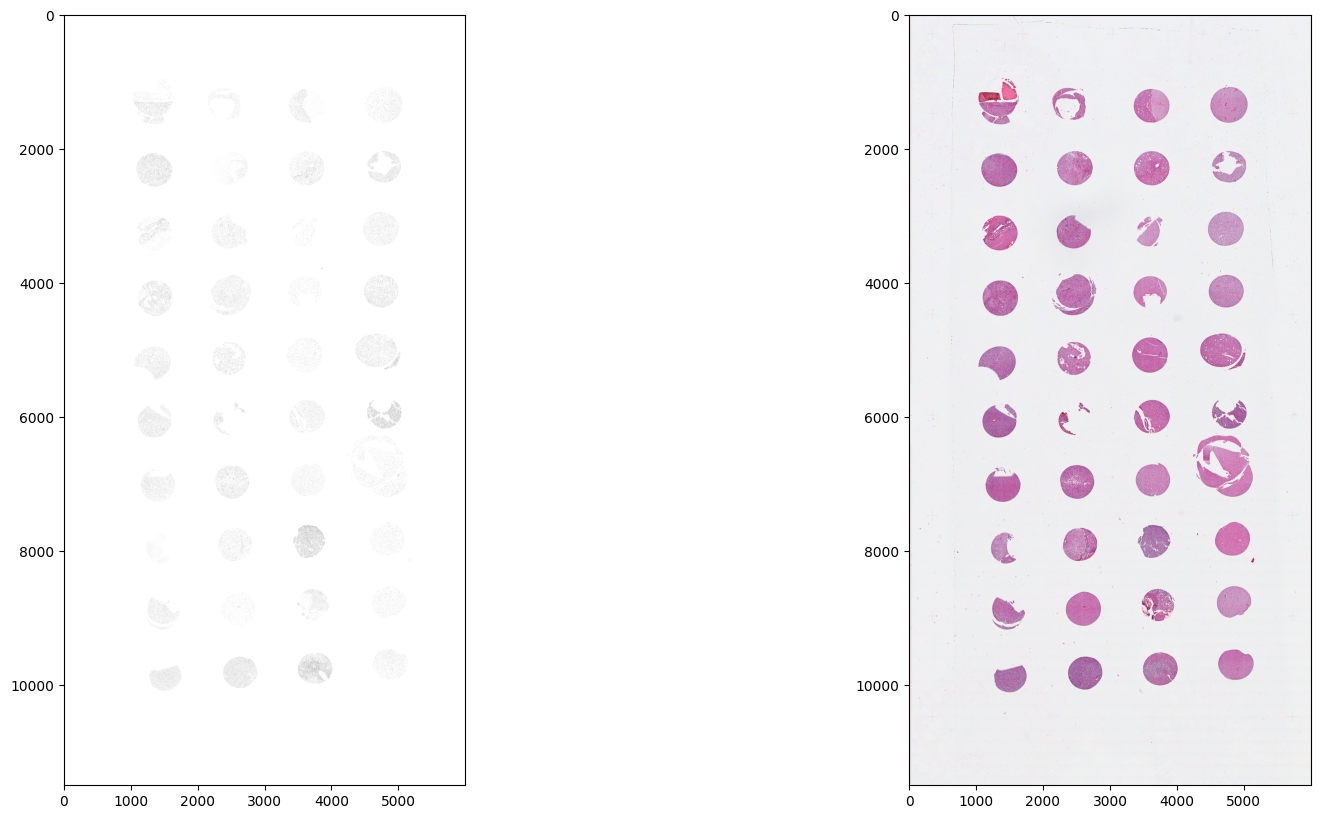

In [7]:
n=2
fig, axes = plt.subplots(1, n, figsize=(n*10, 10))
axes[0].imshow(new_dapi, cmap='gray_r')
axes[1].imshow(new_he)
#axes[2].imshow(met)
#axes[3].imshow(peptide)
#axes[4].imshow(glycan)

for ax in axes:
    ax.axis('on')
    #sns.scatterplot(cells, x='x_location_px', y='y_location_px', ax=ax, s=.1, color='red')
